# Mini-projet géophysique : interpolation de données manquantes

*Contexte* : dans le cadre d'acquisition de données sismiques, des capteurs (récepteurs) sont positionnés le long d'une ligne à la surface de la terre. Chacun enregistre au cours du temps le déplacement des particules (signal oscillant) qui varie lors du passage d'une onde acoustique ou élastique. Cet enregistrement s'appelle une **trace**. C'est une colonne dans les représentation graphiques plus bas.

En pratique, il arrive que certains capteurs soient défaillants ou encore qu'ils ne soient pas présents dans certaines zones (pour des problèmes d'accessibilité par exemple). L'objectif principal du mini-projet est de reconstituer les traces manquantes.

*Hypothèses* : nous ferons l'hypothèse que les **signaux sont essentiellement linéraires** dans les enregistrements (i.e. on peut localement déduire la trace suivante à partir de la trace précédente, avec un décalage en temps qui est proportionnel à la distance entre les traces). L'approximation linéaire est explicitée plus bas.

*Notions abordées* : 
* Lien entre la représentation avant et après transformée de Fourier 2d
* Effets de bords

Pour cela, nous considérons l'approche suivante :
* Transformée de Fourier 2d
* Identification des événements principaux
* Définition d'un masque
* Reconstitution des traces manquantes par transformee de Fourier inverse

L'approche est appliquée sur 3 jeux de données : 
* Donnees simples (un seul événement) : `gpanel1.npy`
* Donnees complexes (4 événements) : `gpanel2.npy`
* Sur vos propres données.

*Attentes* :
* Regard critique sur les résulats obtenus
* Inventivité (pour la troisième application)

*Consignes* :
* **Très important**: pour toutes les figures, bien indiquer les axes avec les bonnes unités et des labels lisibles

In [2]:
# Modules
import numpy as np
import matplotlib.pyplot as plt

**Lecture des données**

In [3]:
# Labelsize (display)
labelsize   = 14
    
# Load the simple input data
# Input data (with missing traces)
gpanel1 = np.load('gpanel1.npy')
# Dense data (with all traces, only for comparison)
panel_dense1 = np.load('panel_dense1.npy')
nt, nx = gpanel1.shape
print("Taille des données :",nt,nx)

# Missing traces (index number)
mtr = [2,5,6,11,12,20,21,22,23]

# Vertical axis -- time
dt   = 3.125e-3  # increment (s)
at   = np.linspace(0,dt*(nt-1),nt)
# Horizontal axis -- space
dx   = 10. # increment (m)
ax   = np.linspace(0,dx*(nx-1),nx)

Taille des données : 400 30


**Affichage des données**

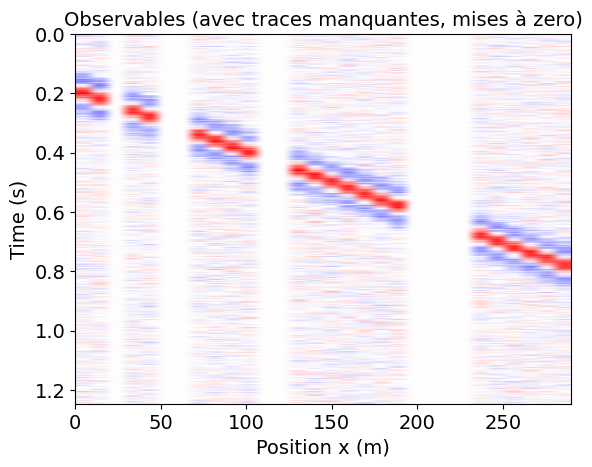

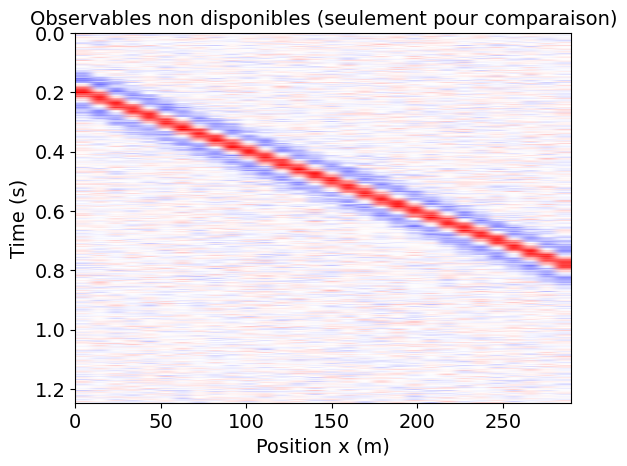

In [4]:
# Display of the input data
vmax    = np.max(np.abs(gpanel1))
fig = plt.figure()
av = plt.subplot(111)
plt.imshow(gpanel1,extent=[ax[0],ax[-1],at[-1],at[0]],aspect='auto')
plt.title('Observables (avec traces manquantes, mises à zero)', fontsize = labelsize)
av.set_ylabel("Time (s)", fontsize = labelsize)
av.set_xlabel("Position x (m)", fontsize = labelsize)
av.tick_params(axis='both', which='major', labelsize=labelsize)
plt.clim([-vmax,vmax])
plt.set_cmap('bwr')

fig = plt.figure()
av = plt.subplot(111)
plt.imshow(panel_dense1,extent=[ax[0],ax[-1],at[-1],at[0]],aspect='auto')
plt.title('Observables non disponibles (seulement pour comparaison)', fontsize = labelsize)
av.set_ylabel("Time (s)", fontsize = labelsize)
av.set_xlabel("Position x (m)", fontsize = labelsize)
av.tick_params(axis='both', which='major', labelsize=labelsize)
plt.clim([-vmax,vmax])
plt.set_cmap('bwr')

# Partie 1. Données simples (7 points)

## Approche théorique

On peut supposer que $$u(t,x) = S\big(t-t_0-p_0(x-x_0)\big)$$

C'est l'approximation linéaire mentionnée plus haut,
avec $S(t)$ une ondelette source, $t_0$ le temps à la position $x=x_0$, et la pente $p_0$ en s/m associée à l'événement. Ici : $t_0=0.2$ s (pour $x_0 = 0$ m) et $p_0=0.002$ s/m.

Tracer la droite définie par $t_0$ et $p_0$ sur les observables (`gpanel1`) pour vérifier qu'elle se superpose bien à l'événement principal.

Calculer l'expression de la transformée de Fourier 2d $\hat{u}(\omega,k)$ de $u(t,x)$ à partir de la transformée de Fourier 1d $\hat{S}(\omega)$ de $S(t)$. En déduire une expression simple de $|\hat{u}|$ en lien avec $|\hat{S}(\omega)|$. Expliquer toujours à partir des équations pourquoi on s'attend à avoir un événement linéaire dans le domaine de Fourier. Pourquoi l'événement passe-t-il par l'origine $(0,0)$ dans le domaine de Fourier? Donner une expression quantitative entre la pente dans le domaine de Fourier $(\omega,k)$ et la pente dans le domaine $(t,x)$.

Pour simplifier l'expression, on peut utiliser

$$\int dx e^{-i k x} = \delta(k)$$

avec $\delta$ la distribution de Dirac.

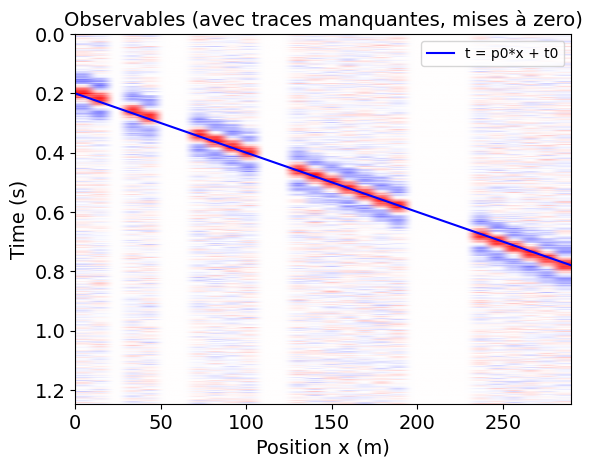

In [5]:
p0 = 0.002
t0 = 0.2
T = p0*ax + t0

vmax    = np.max(np.abs(gpanel1))
fig = plt.figure()
av = plt.subplot(111)
plt.plot(ax, T, "b", label = "t = p0*x + t0")
plt.imshow(gpanel1,extent=[ax[0],ax[-1],at[-1],at[0]],aspect='auto')
plt.title('Observables (avec traces manquantes, mises à zero)', fontsize = labelsize)
av.set_ylabel("Time (s)", fontsize = labelsize)
av.set_xlabel("Position x (m)", fontsize = labelsize)
av.tick_params(axis='both', which='major', labelsize=labelsize)
plt.clim([-vmax,vmax])
plt.set_cmap('bwr')
plt.legend()
plt.show()


**Calcul de la transformée de Fourier 2d $\hat{u}(\omega,k)$ de $u(t,x)$**

Transformée de Fourier 1d : 
$$\hat{S}(\omega) = \int_{\mathbb{R}} S(t)e^{-i\omega t}\,dx$$
Transformée de Fourier 2d : 
$$\hat{u}(\omega, k) = \int_{\mathbb{R}} \int_{\mathbb{R}} u(t,x)e^{-i(\omega t +xk)}\,dtdx$$
$$\hat{u}(\omega, k) = \int_{\mathbb{R}} \int_{\mathbb{R}} S\big(t-t_0-p_0(x-x_0)\big)e^{-i(\omega t +xk)}\,dtdx$$

On fait le changement de variable : $$\tau = t - t_0 - p_0(x-x_0)$$ donc $$dt = d\tau $$

Ainsi, $$\hat{u}(\omega, k) = \int_{\mathbb{R}} \int_{\mathbb{R}} S(\tau)e^{-i\omega(\tau + t_0 + p_0(x-x_0))}e^{-ikx}\,d\tau dx$$
$$\hat{u}(\omega, k) = \int_{\mathbb{R}} S(\tau)e^{-i\omega \tau}d\tau \int_{\mathbb{R}} e^{-i\omega(t_0 + p_0(x-x_0))}e^{-ikx}\,dx$$
$$\hat{u}(\omega, k) = \hat{S}(\omega) e^{-i\omega(t_0 - p_0x_0)} \int_{\mathbb{R}} e^{-ix(k + \omega p_0)}\,dx$$
$$\boxed{\hat{u}(\omega, k) = \hat{S}(\omega) e^{-i\omega(t_0 - p_0x_0)} \delta(k + \omega p_0)}$$

**Calcul de $|\hat{u}(\omega,k)|$**

$$|\hat{u}(\omega,k)| = |\hat{S}(\omega) e^{-i\omega(t_0 - p_0x_0)} \delta(k + \omega p_0)|$$
or : $$|e^{-i\omega(t_0 - p_0x_0)}|=1$$ et $$|\delta(k + \omega p_0)|=\delta(k + \omega p_0)$$
donc : $$\boxed{|\hat{u}(\omega,k)| = |\hat{S}(\omega)| \delta(k + \omega p_0)}$$

**Événement linéaire dans le domaine de Fourier**

La transformée de Fourier est non nulle lorsque les deux phases s'annulent. 
Donc le dirac $\delta(k + \omega p_0) = 0$ presque partout sauf si : $$k=-\omega p_0 \Rightarrow k + \omega p_0 = 0$$
Ainsi, on s'attend à voir un événement linaire dans le domaine de Fourier passant par l'origine $(0,0)$ puisque $(\omega, k) = (0,0)$ vérifie la condition $k + \omega p_0 = 0$.

Donc, dans le domaine de Fourier la pente vaut $-p_0$. 

Dans le domaine $(t,x)$ la pente vaut $p_0$.

## Implémentation
Représenter la transformée de Fourier 2d et bien préciser les axes. Faire le lien entre l'événement dans l'espace $(t,x)$ et celui dans l'espace de Fourier. Comme pour le domaine $(t,x)$, tracer la droite correspondante dans le domaine $(\omega,k)$. Expliquer ce qu'il se passe aux bords dans le domaine de Fourier. N'hésitez pas à zoomer autour de la position centrale $(0,0)$ dans le domaine de Fourier pour une meilleure représentation.

Un événement dans le temps équivaut à un évémenement dans le domaine de Fourier. De plus, les événements verticaux dans le temps deviennent des événements horizontaux dans Fourier. Donc nous avons un lien quantitatif entre les angles. 

Aux bords du domaine de Fourier, on retrouve des artefacts hautes fréquences dû à la périodicité de la FFT.

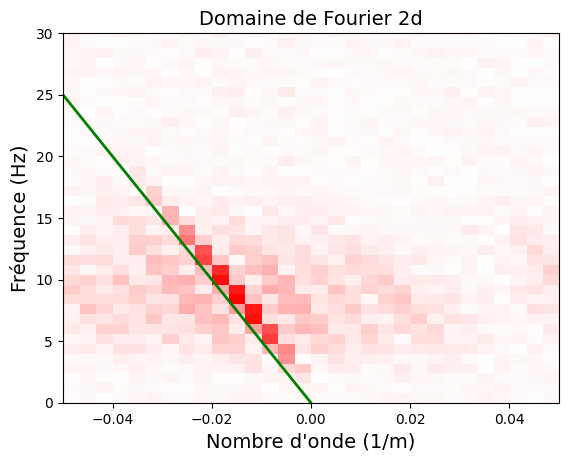

In [58]:
u = np.abs(np.fft.fft2(gpanel1))
fmax = 1/2/dt
kmax = 1/2/dx
af = np.linspace(-fmax,fmax,nt)
ak = np.linspace(-kmax,kmax,nx)

kk0 = -ak/p0

vmax = np.max(np.abs(u))

fig = plt.figure()
av = plt.subplot(111)
plt.imshow(np.fft.fftshift(u), extent=[ak[0],ak[-1], af[-1], af[0]], aspect ='auto')
plt.plot(ak, kk0, color='green', linewidth=2)
plt.clim([-vmax,vmax])
plt.ylim([0,30])
plt.xlim([ak[0],ak[-1]])
plt.title('Domaine de Fourier 2d', fontsize = labelsize)
plt.xlabel("Nombre d'onde (1/m)", fontsize = labelsize)
plt.ylabel("Fréquence (Hz)", fontsize = labelsize)
plt.set_cmap('bwr')

## Définition d'un masque dans le domaine de Fourier 2d
On note $\omega$ la fréquence angulaire et $k$ le nombre d'onde. Dans le domaine de Fourier 2d, on souhaite définir un masque avec des 1 qui couvrent les événements principaux. A partir de $(\omega,k)=(0,0)$, faire des sommations selon différentes pentes (dans le domaine de Fourier, après avoir pris le module des valeurs complexes) et tracer la valeur de ces sommes en fonction de la pente. On s'attend à ce que une valeur ressorte. Calculer une fonction qui sélectionne automatiquement cette valeur et construire un masque dans le domaine de Fourier 2d qui vaut 1 autour de la valeur principale et 0 en dehors.

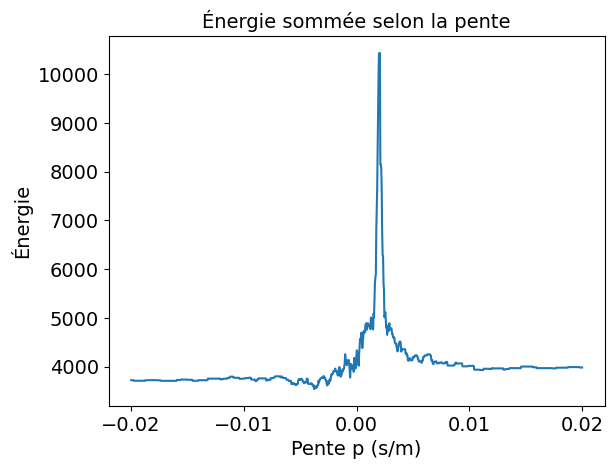

Pente détectée : p = 0.0020 s/m


In [60]:
af_shift = np.fft.fftshift(np.fft.fftfreq(nt, d=dt))
ak_shift = np.fft.fftshift(np.fft.fftfreq(nx, d=dx))

U_mod = np.fft.fftshift(np.abs(np.fft.fft2(gpanel1)))

# Sommation selon les pentes
pentes = np.linspace(-0.02, 0.02, 1000)
energie = np.zeros(len(pentes))
for i, p in enumerate(pentes):
    for j, f in enumerate(af_shift):
        k_target = -p * f
        i_k = np.argmin(np.abs(ak_shift - k_target))
        energie[i] += U_mod[j, i_k]

fig = plt.figure()
av = plt.subplot(111)
plt.plot(pentes, energie)
plt.title("Énergie sommée selon la pente", fontsize=labelsize)
plt.xlabel("Pente p (s/m)", fontsize=labelsize)
plt.ylabel("Énergie", fontsize=labelsize)
av.tick_params(axis='both', which='major', labelsize=labelsize)
plt.show()

p_detected = pentes[np.argmax(energie)]
print(f"Pente détectée : p = {p_detected:.4f} s/m")

# Masque avec delta_f adapté aux vraies fréquences
KK, FF = np.meshgrid(ak_shift, af_shift)
delta_f = 5.0   # Hz — à ajuster entre 2 et 20
mask = (np.abs(FF + KK / p_detected) < delta_f).astype(float)

## Application du masque et analyse des résultats
Appliquer le masque (sur les données après transformée de Fourier 2d, sans prendre le module des valeurs), puis appliquer la transformée de Fourier inverse. Commenter les résultats. Si nécessaire, revenir à la question précédente pour changer la forme du masque et avoir une meilleure interpolation des données. Expliquer ces changements. Discuter de l'importance du masque.

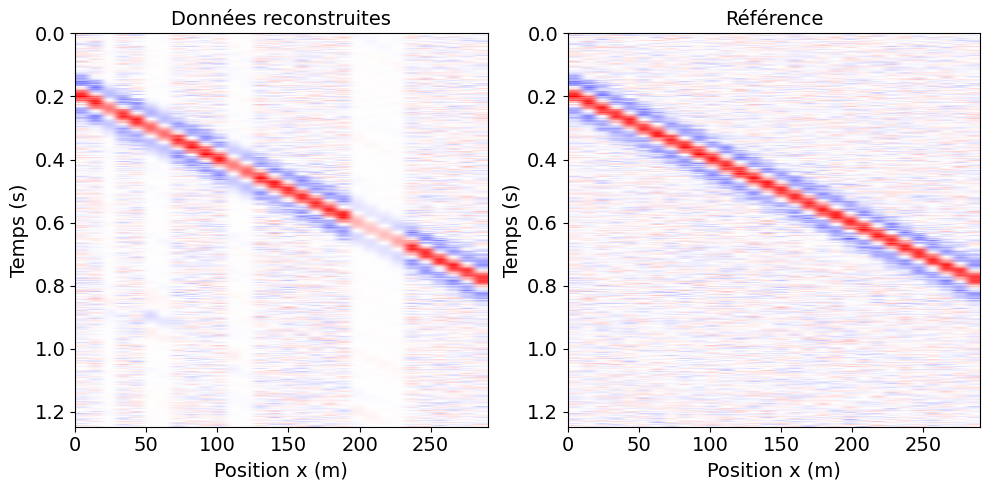

In [66]:
# TF 2D complexe de gpanel1 original (avec zéros)
U_complex = np.fft.fftshift(np.fft.fft2(gpanel1))
U_masked  = U_complex * mask
gpanel1_rec = np.real(np.fft.ifft2(np.fft.ifftshift(U_masked)))

# Remplacement uniquement des traces manquantes
gpanel1_final = gpanel1.copy()
gpanel1_final[:, mtr] = gpanel1_rec[:, mtr]

vmax = np.max(np.abs(panel_dense1))
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for a, data, title in zip(axes,
                           [gpanel1_final, panel_dense1],
                           ['Données reconstruites', 'Référence']):
    a.imshow(data, extent=[ax[0], ax[-1], at[-1], at[0]], aspect='auto', cmap='bwr')
    a.images[0].set_clim([-vmax, vmax])
    a.set_title(title, fontsize=labelsize)
    a.set_xlabel('Position x (m)', fontsize=labelsize)
    a.set_ylabel('Temps (s)', fontsize=labelsize)
    a.tick_params(axis='both', which='major', labelsize=labelsize)
plt.tight_layout()
plt.show()

# Partie 2. Données complexes (7 points)

Recommencer la même procédure (interpolation des données) sur les données plus complexes (`gpanel2.npy`). Analyser les similitudes et différences, et en particulier les difficultés rencontrées.

Les pentes sont : 
$p_0 = 0.006$, $p_1 = 0.002$, $p_2 = -0.004$ et $p_3 = -0.0005$ en s/m 
et les temps associes (pour $x_0=0$ m) : $t_0 = 0.1$, $t_1 = 0.3$, $t_2 = 1.1$ et $t_3 = 1.8$ en s.


In [9]:
# Load the input data
# Input data (with missing traces)
gpanel2 = np.load('gpanel2.npy')
# Dense data (with all traces, only for comparison)
panel_dense2 = np.load('panel_dense2.npy')
nt, nx = gpanel2.shape
print("Taille des données :",nt,nx)


Taille des données : 400 30


**Affichage des données**

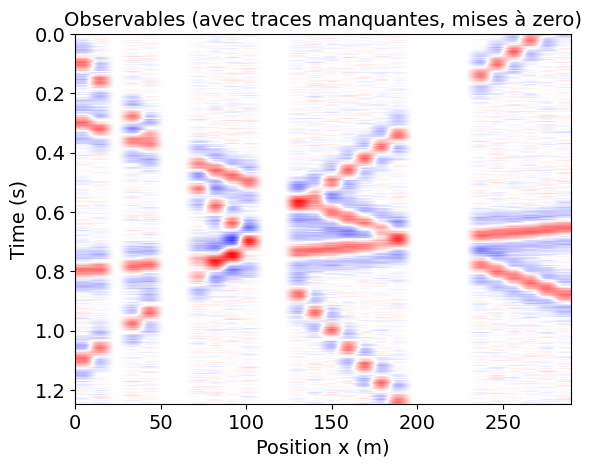

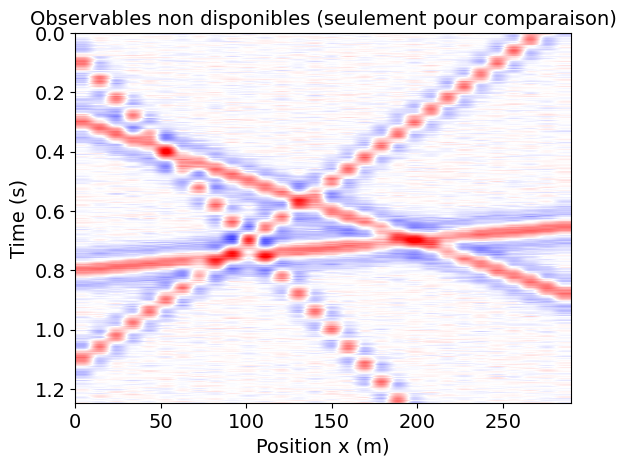

In [ ]:
# Display of the input data
vmax    = np.max(np.abs(gpanel2))
fig = plt.figure()
av = plt.subplot(111)
plt.imshow(gpanel2,extent=[ax[0],ax[-1],at[-1],at[0]],aspect='auto')
plt.title('Observables (avec traces manquantes, mises à zero)', fontsize = labelsize)
av.set_ylabel("Time (s)", fontsize = labelsize)
av.set_xlabel("Position x (m)", fontsize = labelsize)
av.tick_params(axis='both', which='major', labelsize=labelsize)
plt.clim([-vmax,vmax])
plt.set_cmap('bwr')

fig = plt.figure()
av = plt.subplot(111)
plt.imshow(panel_dense2,extent=[ax[0],ax[-1],at[-1],at[0]],aspect='auto')
plt.title('Observables non disponibles (seulement pour comparaison)', fontsize = labelsize)
av.set_ylabel("Time (s)", fontsize = labelsize)
av.set_xlabel("Position x (m)", fontsize = labelsize)
av.tick_params(axis='both', which='major', labelsize=labelsize)
plt.clim([-vmax,vmax])
plt.set_cmap('bwr')

On prend $t_3 = 0.8 s$ car sinon la droite obtenue ne correspond pas aux données. 

/var/folders/kb/gjppbzt97fs925mr5x61pdj80000gn/T/ipykernel_16628/3156958435.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(ax, T[i], "b", label = f"t = p{i}*ax + t{i}", color = f"C{i}")


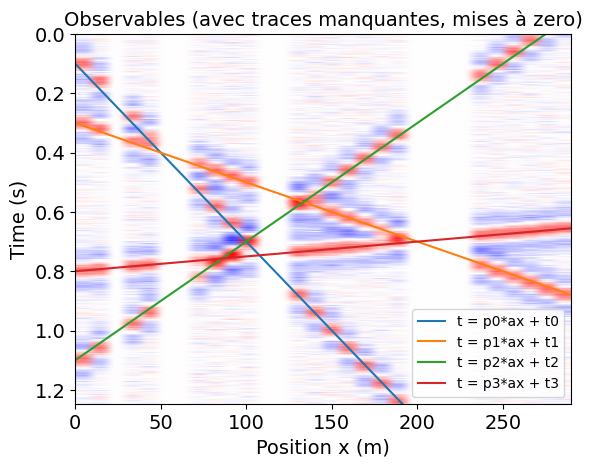

In [20]:
P = np.array([0.006, 0.002, -0.004, -0.0005])
S = np.array([0.1, 0.3, 1.1, 0.8])
T = np.array([P[i]*ax + S[i] for i in range(len(P))])

vmax    = np.max(np.abs(gpanel2))
fig = plt.figure()
av = plt.subplot(111)
plt.imshow(gpanel2,extent=[ax[0],ax[-1],at[-1],at[0]],aspect='auto')
for i in range(len(T)):
    plt.plot(ax, T[i], "b", label = f"t = p{i}*ax + t{i}", color = f"C{i}")
plt.title('Observables (avec traces manquantes, mises à zero)', fontsize = labelsize)
av.set_ylabel("Time (s)", fontsize = labelsize)
av.set_xlabel("Position x (m)", fontsize = labelsize)
av.tick_params(axis='both', which='major', labelsize=labelsize)
plt.clim([-vmax,vmax])
plt.set_cmap('bwr')
plt.legend()
plt.ylim([at[-1], at[0]])
plt.show()

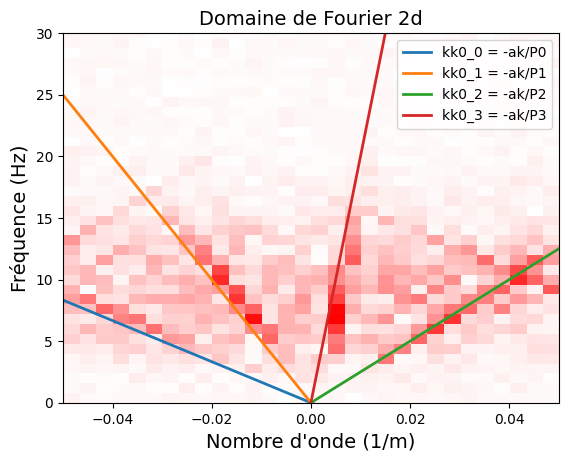

In [30]:
u = np.abs(np.fft.fft2(gpanel2))
fmax = 1/2/dt
kmax = 1/2/dx
af = np.linspace(-fmax,fmax,nt)
ak = np.linspace(-kmax,kmax,nx)

kk0 = np.array([-ak/P[i] for i in range(len(P))])

vmax = np.max(np.abs(u))

fig = plt.figure()
av = plt.subplot(111)
plt.imshow(np.fft.fftshift(u), extent=[ak[0],ak[-1], af[-1], af[0]], aspect ='auto')
for i in range(4):
    plt.plot(ak, kk0[i], color=f"C{i}", linewidth=2, label=f"kk0_{i} = -ak/P{i}" )
plt.clim([-vmax,vmax])
plt.ylim([0,30])
plt.xlim([ak[0],ak[-1]])
plt.title('Domaine de Fourier 2d', fontsize = labelsize)
plt.xlabel("Nombre d'onde (1/m)", fontsize = labelsize)
plt.ylabel("Fréquence (Hz)", fontsize = labelsize)
plt.legend()
plt.set_cmap('bwr')


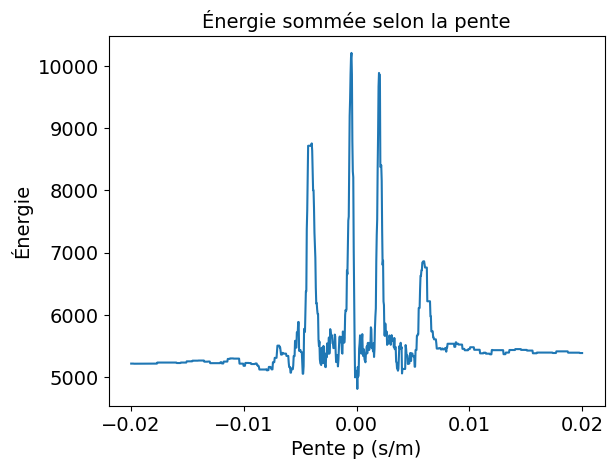

Pente détectée 0 : p = -0.0005 s/m
Pente détectée 1 : p = 0.0020 s/m
Pente détectée 2 : p = -0.0040 s/m
Pente détectée 3 : p = 0.0059 s/m


In [81]:
af_shift = np.fft.fftshift(np.fft.fftfreq(nt, d=dt))
ak_shift = np.fft.fftshift(np.fft.fftfreq(nx, d=dx))

U_mod = np.fft.fftshift(np.abs(np.fft.fft2(gpanel2)))

# Sommation selon les pentes
pentes = np.linspace(-0.02, 0.02, 1000)
energie = np.zeros(len(pentes))
for i, p in enumerate(pentes):
    for j, f in enumerate(af_shift):
        k_target = -p * f
        i_k = np.argmin(np.abs(ak_shift - k_target))
        energie[i] += U_mod[j, i_k]

fig = plt.figure()
av = plt.subplot(111)
plt.plot(pentes, energie)
plt.title("Énergie sommée selon la pente", fontsize=labelsize)
plt.xlabel("Pente p (s/m)", fontsize=labelsize)
plt.ylabel("Énergie", fontsize=labelsize)
av.tick_params(axis='both', which='major', labelsize=labelsize)
plt.show()

# Détection des 4 pentes dominantes
p_detected = []
energie_copy = energie.copy()
fenetre = 50  # nombre de points à supprimer autour du pic (à ajuster)

for i in range(4):
    j = np.argmax(energie_copy)
    p_detected.append(pentes[j])
    # Supprime une fenêtre autour du pic
    j_min = max(0, j - fenetre)
    j_max = min(len(energie_copy), j + fenetre)
    energie_copy[j_min:j_max] = np.min(energie_copy)
    print(f"Pente détectée {i} : p = {p_detected[i]:.4f} s/m")

# Masque combinant les 4 pentes
KK, FF = np.meshgrid(ak_shift, af_shift)
delta_f = 5.0
mask = np.zeros((nt, nx))
for p in p_detected:
    mask += (np.abs(FF + KK / p) < delta_f).astype(float)
mask = (mask > 0).astype(float)  # ramène à 0/1

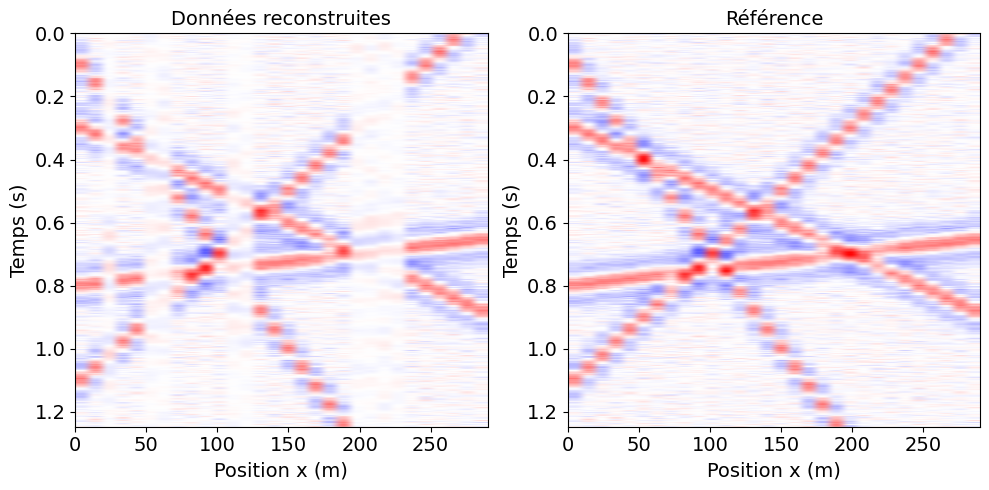

In [83]:
# TF 2D complexe de gpanel1 original (avec zéros)
U_complex = np.fft.fftshift(np.fft.fft2(gpanel2))
U_masked  = U_complex * mask
gpanel2_rec = np.real(np.fft.ifft2(np.fft.ifftshift(U_masked)))

# Remplacement uniquement des traces manquantes
gpanel2_final = gpanel2.copy()
gpanel2_final[:, mtr] = gpanel2_rec[:, mtr]

vmax = np.max(np.abs(panel_dense2))
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for a, data, title in zip(axes,
                           [gpanel2_final, panel_dense2],
                           ['Données reconstruites', 'Référence']):
    a.imshow(data, extent=[ax[0], ax[-1], at[-1], at[0]], aspect='auto', cmap='bwr')
    a.images[0].set_clim([-vmax, vmax])
    a.set_title(title, fontsize=labelsize)
    a.set_xlabel('Position x (m)', fontsize=labelsize)
    a.set_ylabel('Temps (s)', fontsize=labelsize)
    a.tick_params(axis='both', which='major', labelsize=labelsize)
plt.tight_layout()
plt.show()

## Analyse des résultats 

La reconstruction des traces manquantes est moins fidèle que pour la partie 1. 
Plusieurs raisons expliquent ces difficultés :

**Superposition des événements dans le domaine de Fourier**  
Avec 4 événements de pentes différentes, les droites $k = -p_i \cdot f$ se croisent 
près de l'origine $(0,0)$. Le masque d'une pente peut donc capturer de l'énergie 
appartenant à un autre événement, ce qui introduit des artefacts dans la reconstruction.

**Pentes proches**  
Les pentes $p_1 = 0.002$ s/m et $p_3 = -0.0005$ s/m sont très proches de zéro et 
difficiles à séparer. Leurs droites dans le domaine de Fourier sont quasi-confondues 
près de l'origine, ce qui rend leur discrimination difficile lors de la détection automatique.

**Largeur du masque**  
Avec 4 masques combinés, la bande couverte dans le domaine de Fourier est plus large 
qu'en partie 1. Cela permet de capturer l'énergie des 4 événements mais au prix d'une 
sélectivité réduite : davantage de bruit et d'artefacts sont conservés lors de la 
transformée de Fourier inverse.

**Conclusion**  
L'approche par masque dans le domaine de Fourier reste efficace pour des données simples 
(un seul événement linéaire), mais montre ses limites dès que plusieurs événements 
coexistent avec des pentes proches ou se croisant. Une approche plus sophistiquée 
(masques adaptatifs, seuillage itératif) serait nécessaire pour améliorer la reconstruction.

# Partie 3. Analyse des limites de l'approche (6 points)
Proposer une nouvelle application sur votre propre jeu de donnees. Vous pouvez par exemple :
* ajouter du bruit sur gpanel1 ou gpanel2
* enlever encore plus de données en entrée (plus de traces blanches) 
* tester sur vos propres données / sur des images récupérées sur internet

Illustrer et discuter une limite (ou plusieurs) que rencontre l'interpolation dans le domaine de Fourier.

**Cette dernière partie est très ouverte et je fais appel à votre créativité.**